In [2]:
%pip install torch torchvision matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 5.4 MB/s  0:00:23 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 5.9 MB/s  0:00:006.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 4.1 MB/s  0:00:01m 4.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 28.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [torchvision] 5/6 [torchvision]]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor()
])

In [9]:
import os
from torchvision import datasets

dataset_path = "./images_dataSAT"

# Remove the notebook checkpoint folder if it exists
checkpoint_path = os.path.join(dataset_path, ".ipynb_checkpoints")
if os.path.isdir(checkpoint_path):
    import shutil
    shutil.rmtree(checkpoint_path)

imagefolder_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=custom_transform
)

print("Classes:", imagefolder_dataset.classes)
print("Total images:", len(imagefolder_dataset))

Classes: ['class_0_non_agri', 'class_1_agri']
Total images: 6000


In [10]:
# Task 3: Print class names and class indices

print("Class names and indices:")

for class_name, class_index in imagefolder_dataset.class_to_idx.items():
    print(f"{class_name}: {class_index}")

Class names and indices:
class_0_non_agri: 0
class_1_agri: 1


In [11]:
# Task 4: Create a DataLoader and retrieve a batch

from torch.utils.data import DataLoader

imagefolder_loader = DataLoader(
    imagefolder_dataset,
    batch_size=4,
    shuffle=True
)

# Retrieve one batch
images, labels = next(iter(imagefolder_loader))

# Display shapes
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([4, 3, 64, 64])
Labels batch shape: torch.Size([4])


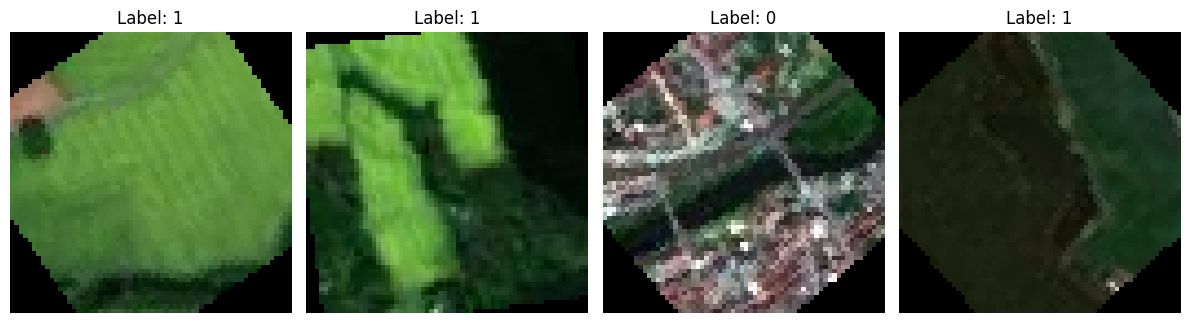

In [12]:
# Task 5: Display images from the batch

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    # Convert image from (C, H, W) to (H, W, C)
    image = images[i].permute(1, 2, 0).numpy()

    axes[i].imshow(image)
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()